<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_9_Hybrid_NPE_NDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 9 — Dual hybrid neural posterior and density estimation

The previous exercises were frequentist: learned densities and density ratios were assembled into a likelihood and then profiled. This exercise develops the Bayesian dual construction described in the hybrid NPE note:

1. train a conditional normalizing flow $q_\phi(\theta\mid x)$ by neural posterior estimation (NPE);
2. freeze it and train a four-member matched-$x$ ensemble for the residual posterior ratio;
3. show that the hybrid posterior is substantially closer to truth than the flow alone;
4. train the dual observation-space hNDE model $q_\eta(x)\,r_{\rm L}(x;\theta)$ with a second four-member ratio ensemble;
5. verify that the posterior-space and likelihood-space constructions agree;
6. use the dual model for posterior-predictive generation, absolute evidence, a nuisance-prior/auxiliary update, and selection integrals without further simulator calls.

All normalizing flows in this notebook are the **same rational-quadratic spline coupling flow** used in Exercises 4 and 5. The likelihood is analytically available for validation in this pedagogical model, but it is never supplied to either flow or classifier during training.


In [1]:
## ============================================================================
# Google Colab setup — run me first. Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = True

def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)
    run(sys.executable, "-m", "pip", "install", "-q", "nflows")
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
else:
    # This covers execution from either the notebook directory or repo root.
    for candidate in [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
    ]:
        if (candidate / "utils_hnpe.py").exists():
            sys.path.insert(0, str(candidate.resolve()))
            break

print("Working directory:", Path.cwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## A small Bayesian problem with a genuine nuisance parameter

We use

$$
  \theta=(\mu,\alpha),
$$

where $\mu$ is the parameter of interest and $\alpha$ is a detector-calibration nuisance. The three reconstructed observables are conditionally independent Gaussians,

$$
\begin{aligned}
  x_1 &\sim \mathcal N(\mu+0.8\alpha,\;0.95^2),\\
  x_2 &\sim \mathcal N(0.72\mu^2-0.4\alpha,\;0.38^2),\\
  x_3 &\sim \mathcal N(0.8\cos\mu+0.3\alpha,\;0.30^2).
\end{aligned}
$$

The quadratic and cosine responses make the posterior non-Gaussian and, for the chosen observation, bimodal in $\mu$. The scale-like nuisance shifts all three means coherently, echoing the detector response uncertainty in Exercise 8.

The simulation design is a factorized defensive mixture,

$$
  \rho(\mu)=0.9\,\mathcal N(0,1.5^2)+0.1\,\mathcal N(0,4^2),\qquad
  \rho(\alpha)=0.9\,\mathcal N(0,1^2)+0.1\,\mathcal N(0,3^2).
$$

Its broad components make later prior changes possible without creating a support mismatch. An optional auxiliary calibration is kept outside all neural training:

$$
  a\mid\alpha\sim\mathcal N(\alpha,\sigma_a^2).
$$


In [2]:
import gc
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import logsumexp
from scipy.stats import norm

from utils_dual_hnde import (
    conditional_flow_c2st,
    conditional_log_normalizer,
    conditional_normalization_diagnostics,
    conditional_residual_log_ratio,
    importance_tail_summary,
    ratio_member_tail_diagnostics,
    train_conditional_log_normalizer,
)
from utils_hnpe import (
    ratio_classifier_ensemble_logit,
    sample_spline_flow,
    spline_flow_log_prob,
    train_ratio_classifier,
    train_spline_flow,
)
from utils_plotting import export_standalone_figure_script

SEED = 19092026
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FAST_MODE = False
LOAD_IF_AVAILABLE = False
RUN_TAG = "fast" if FAST_MODE else "full"
MODEL_DIR = Path("models_exercise9_dual_conditional_reference_v1") / RUN_TAG
RATIO_MODEL_DIR = MODEL_DIR / "paired_raw_ratio_ensemble4"
FIGURE_SCRIPT_DIR = Path("exercise9_figures_scripts")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RATIO_MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

if FAST_MODE:
    N_FLOW, N_RATIO = 35_000, 80_000
    N_POSTERIOR, N_REFERENCE = 80_000, 35_000
    N_NORMALIZER_CONTEXT, N_NORMALIZER_REFERENCE = 512, 32
    FLOW_EPOCHS, RATIO_EPOCHS = 12, 24
else:
    N_FLOW, N_RATIO = 250_000, 500_000
    N_POSTERIOR, N_REFERENCE = 500_000, 250_000
    N_NORMALIZER_CONTEXT, N_NORMALIZER_REFERENCE = 2_048, 64
    FLOW_EPOCHS, RATIO_EPOCHS = 50, 70

# Both q_phi(theta|x) and q_eta(x|theta) use this spline family.
FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 10,
    "hidden_features": 512,
    "hidden_layers": 4,
    "spline_num_bins": 16,
    "spline_tail_bound": 5.0,
    "dropout_probability": 0.0,
}
FLOW_TRAINING_CONFIG = {
    "batch_size": 1024,
    "n_epochs": FLOW_EPOCHS,
    "learning_rate": 1.0e-3,
    "min_learning_rate": 1.0e-11,
    "validation_fraction": 0.2,
    "patience": 10,
    "gradient_clip": 5.0,
}
RATIO_MODEL_CONFIG = {
    "hidden_features": 1024,
    "hidden_layers": 4,
    "dropout_probability": 0.0,
}
RATIO_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": RATIO_EPOCHS,
    "learning_rate": 1.0e-3,
    "lr_scheduler": "step",
    "lr_scheduler_factor": 0.01,
    "lr_scheduler_patience": 10,
    "validation_fraction": 0.2,
    "patience": 30,
    "gradient_clip": 5.0,
}
RATIO_ENSEMBLE_SIZE = 4


def export_exercise9_figure(fig, script_name):
    return export_standalone_figure_script(
        fig, script_name=script_name, output_dir=FIGURE_SCRIPT_DIR
    )


def plot_ratio_training_histories(packs, title, script_name):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
    for member, pack in enumerate(packs):
        history = pack.get("history", {})
        epochs = np.arange(1, len(history.get("validation", [])) + 1)
        axes[0].plot(
            epochs, history.get("validation", []), label=f"member {member}"
        )
        axes[1].step(
            epochs, history.get("learning_rate", []), where="post"
        )
    axes[0].set(xlabel="epoch", ylabel="validation BCE", title=title)
    axes[0].legend(ncol=2)
    axes[1].set(
        xlabel="epoch", ylabel="learning rate", yscale="log"
    )
    axes[1].set_title(r"step schedule: $10^{-3},10^{-5},10^{-7},\ldots$")
    for ax in axes:
        ax.grid(alpha=0.25)
    fig.tight_layout()
    export_exercise9_figure(fig, script_name)
    plt.show()


print(f"Raw ratio ensemble size: {RATIO_ENSEMBLE_SIZE}")
print("Ratio validation split: paired simulator groups")
print(f"Standalone figure scripts will be written to {FIGURE_SCRIPT_DIR}/")

SIMULATOR_SIGMA = np.array([0.95, 0.38, 0.30])
X_OBS = np.array([0.40, 1.35, 0.12])
DEFENSIVE_EPSILON = 0.02


Using device: cuda
Raw ratio ensemble size: 4
Ratio validation split: paired simulator groups
Standalone figure scripts will be written to exercise9_figures_scripts/


In [3]:
def _mixture_logpdf(values, core_sigma, broad_sigma):
    values = np.asarray(values, dtype=float)
    return logsumexp(
        np.stack(
            [
                np.log(0.9) + norm.logpdf(values, 0.0, core_sigma),
                np.log(0.1) + norm.logpdf(values, 0.0, broad_sigma),
            ]
        ),
        axis=0,
    )


def design_mu_logpdf(mu):
    return _mixture_logpdf(mu, 1.5, 4.0)


def design_alpha_logpdf(alpha):
    return _mixture_logpdf(alpha, 1.0, 3.0)


def design_logpdf(theta):
    theta = np.atleast_2d(np.asarray(theta, dtype=float))
    return design_mu_logpdf(theta[:, 0]) + design_alpha_logpdf(theta[:, 1])


def _sample_mixture(n, core_sigma, broad_sigma, rng):
    broad = rng.random(int(n)) < 0.1
    sigma = np.where(broad, broad_sigma, core_sigma)
    return rng.normal(0.0, sigma)


def sample_design(n, rng):
    return np.column_stack(
        [
            _sample_mixture(n, 1.5, 4.0, rng),
            _sample_mixture(n, 1.0, 3.0, rng),
        ]
    ).astype(np.float32)


def simulator_mean(theta):
    theta = np.atleast_2d(np.asarray(theta, dtype=float))
    mu, alpha = theta[:, 0], theta[:, 1]
    return np.column_stack(
        [
            mu + 0.8 * alpha,
            0.72 * mu**2 - 0.4 * alpha,
            0.8 * np.cos(mu) + 0.3 * alpha,
        ]
    )


def simulate(theta, rng):
    mean = simulator_mean(theta)
    return (mean + rng.normal(size=mean.shape) * SIMULATOR_SIGMA).astype(
        np.float32
    )


def log_likelihood(x, theta):
    """Used only for truth validation; never passed to a network."""
    x = np.asarray(x, dtype=float)
    mean = simulator_mean(theta)
    return np.sum(norm.logpdf(x, loc=mean, scale=SIMULATOR_SIGMA), axis=1)


def auxiliary_loglikelihood(alpha, a_observed, sigma_a):
    return norm.logpdf(a_observed, loc=np.asarray(alpha), scale=sigma_a)


def normalized_weights_from_log(log_weights):
    log_weights = np.asarray(log_weights, dtype=float)
    weights = np.exp(log_weights - logsumexp(log_weights))
    return weights


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    return 1.0 / np.sum(weights**2)


print("Observed x:", X_OBS)
print("log p(x_obs | mu=1.2, alpha=-0.35) =", log_likelihood(X_OBS, [[1.2, -0.35]])[0])


Observed x: [0.4  1.35 0.12]
log p(x_obs | mu=1.2, alpha=-0.35) = -0.8110336988445328


## Independent simulation splits and honest paired validation

Each learned object receives a separate simulator sample:

| split | use |
|---|---|
| $\mathcal D_\phi$ | train the conditional NPE $q_\phi(\theta\mid x)$ |
| $\mathcal D_{r_{\rm P}}$ | train the posterior-residual ensemble |
| $\mathcal D_\eta$ | train the conditional likelihood flow $q_\eta(x\mid\theta)$ |
| $\mathcal D_{c}$ | train the conditional likelihood-residual ensemble |

Each ratio datum produces two classifier rows. For hNPE they share the
same $x_i$; for conditional-reference hNDE they share the same
$\theta_i$. The simulator indices are split **before** the two class rows
are constructed, so both members of a pair always remain together in
training or validation. This prevents a high-capacity classifier from
memorizing the shared coordinate and producing an artificially good
validation BCE.

Four independently initialized classifiers represent each residual.
Their positive ratio predictions are averaged arithmetically. The
member-wise tails and their shares in that arithmetic average are
inspected explicitly below. No affine, histogram, or isotonic post-hoc
calibration is used.


## 1. Train the quadratic-spline NPE reference

Forward simulation provides pairs

$$
  \theta_i\sim\rho(\theta),\qquad x_i\sim p(x\mid\theta_i).
$$

Conditional maximum likelihood minimizes

$$
  -\frac1N\sum_i\log q_\phi(\theta_i\mid x_i),
$$

so $q_\phi$ approaches the design posterior $p_\rho(\theta\mid x)$. We intentionally keep this flow modest: the exercise needs a realistic residual error to correct, and the chosen observation has a subdominant second mode that an amortized finite-capacity flow can model imperfectly.


In [4]:
rng = np.random.default_rng(SEED + 10)
theta_phi = sample_design(N_FLOW, rng)
x_phi = simulate(theta_phi, rng)

q_phi = train_spline_flow(
    theta_phi,
    context=x_phi,
    checkpoint=MODEL_DIR / "q_phi_conditional_posterior.pt",
    model_config=FLOW_MODEL_CONFIG,
    training_config=FLOW_TRAINING_CONFIG,
    device=device,
    seed=SEED + 11,
    load_if_available=LOAD_IF_AVAILABLE,
)

del theta_phi, x_phi
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Training conditional quadratic-spline flow on 200,000 rows
  epoch 01/50: train=1.2203, validation=0.9622
  epoch 02/50: train=1.0043, validation=0.9668
  epoch 03/50: train=0.9769, validation=1.0096
  epoch 04/50: train=0.9386, validation=0.9623
  epoch 05/50: train=0.8473, validation=0.8284
  epoch 06/50: train=0.8262, validation=0.8232
  epoch 07/50: train=0.8184, validation=0.8130
  epoch 08/50: train=0.8168, validation=0.8254
  epoch 09/50: train=0.8132, validation=0.8140
  epoch 10/50: train=0.8145, validation=0.8196
  epoch 11/50: train=0.7973, validation=0.7984
  epoch 12/50: train=0.7945, validation=0.7992
  epoch 13/50: train=0.7935, validation=0.7964
  epoch 14/50: train=0.7936, validation=0.7991
  epoch 15/50: train=0.7935, validation=0.7962
  epoch 16/50: train=0.7916, validation=0.7998
  epoch 17/50: train=0.7929, validation=0.7973
  epoch 18/50: train=0.7932, validation=0.7965
  epoch 19/50: train=0.7868, validation=0.7944
  epoch 20/50: train=0.7856, validation=0.7932
 

## 2. Add defensive support and train the posterior residual

A flow that assigns negligible probability to a posterior mode cannot be
repaired by finite importance weights. We therefore use

$$
q_{\phi,\epsilon}(\theta\mid x)
=(1-\epsilon)q_\phi(\theta\mid x)+\epsilon\rho(\theta),
\qquad \epsilon=0.02.
$$

The classifier learns

$$
r_{\rm P}(\theta;x)
=\frac{p_\rho(\theta\mid x)}
{q_{\phi,\epsilon}(\theta\mid x)}.
$$

Positive and negative rows with the same observation are kept in the
same train/validation group:

$$
\begin{array}{lll}
y=1:& \theta_i\sim\rho,&x_i\sim p(x\mid\theta_i),\\
y=0:& \widetilde\theta_i\sim q_{\phi,\epsilon}(\theta\mid x_i),
&\text{the same }x_i.
\end{array}
$$


In [5]:
def sample_defensive_matched(context, rng):
    context = np.atleast_2d(np.asarray(context, dtype=np.float32))
    flow_draws = sample_spline_flow(q_phi, 1, context=context)[:, 0, :]
    design_draws = sample_design(len(context), rng)
    use_design = rng.random(len(context)) < DEFENSIVE_EPSILON
    draws = flow_draws.copy()
    draws[use_design] = design_draws[use_design]
    return draws.astype(np.float32)


def sample_defensive_fixed(x, n, rng):
    x = np.atleast_2d(np.asarray(x, dtype=np.float32))
    flow_draws = sample_spline_flow(q_phi, int(n), context=x)
    design_draws = sample_design(n, rng)
    use_design = rng.random(int(n)) < DEFENSIVE_EPSILON
    flow_draws[use_design] = design_draws[use_design]
    return flow_draws.astype(np.float32)


def defensive_logpdf(theta, x):
    theta = np.atleast_2d(np.asarray(theta, dtype=np.float32))
    x = np.atleast_2d(np.asarray(x, dtype=np.float32))
    if len(x) == 1:
        x = np.repeat(x, len(theta), axis=0)
    log_q_phi = spline_flow_log_prob(q_phi, theta, context=x)
    return np.logaddexp(
        np.log1p(-DEFENSIVE_EPSILON) + log_q_phi,
        np.log(DEFENSIVE_EPSILON) + design_logpdf(theta),
    )


rng = np.random.default_rng(SEED + 20)
theta_rp_positive = sample_design(N_RATIO, rng)
x_rp_matched = simulate(theta_rp_positive, rng)
theta_rp_negative = sample_defensive_matched(x_rp_matched, rng)

rp_positive = np.column_stack([theta_rp_positive, x_rp_matched])
rp_negative = np.column_stack([theta_rp_negative, x_rp_matched])
paired_ids_rp = np.arange(N_RATIO, dtype=np.int64)
r_p_ensemble = []
for member in range(RATIO_ENSEMBLE_SIZE):
    print("\n" + "=" * 76)
    print(
        f"Training posterior-residual member "
        f"{member + 1}/{RATIO_ENSEMBLE_SIZE}"
    )
    print("=" * 76)
    r_p_ensemble.append(
        train_ratio_classifier(
            rp_positive,
            rp_negative,
            checkpoint=(
                RATIO_MODEL_DIR
                / f"r_p_posterior_residual_member{member}.pt"
            ),
            model_config=RATIO_MODEL_CONFIG,
            training_config=RATIO_TRAINING_CONFIG,
            device=device,
            seed=SEED + 21 + 100 * member,
            load_if_available=LOAD_IF_AVAILABLE,
            paired_group_ids=paired_ids_rp,
        )
    )

assert all(
    pack["history"].get("split_strategy") == "paired_groups"
    for pack in r_p_ensemble
)
rp_tail_rows = min(25_000, len(rp_negative))
display(
    ratio_member_tail_diagnostics(
        r_p_ensemble,
        rp_negative[:rp_tail_rows],
        path="hNPE posterior residual",
    ).style.format(precision=4).hide(axis="index")
)

del (
    theta_rp_positive,
    theta_rp_negative,
    x_rp_matched,
    rp_positive,
    rp_negative,
    paired_ids_rp,
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



Training posterior-residual member 1/4
Training balanced ratio classifier on 500,000 rows per class with paired_groups validation
  epoch 01/70: lr=1.000e-03, train=0.5749, validation=0.5619
  epoch 02/70: lr=1.000e-03, train=0.5604, validation=0.5616
  epoch 03/70: lr=1.000e-03, train=0.5586, validation=0.5582
  epoch 04/70: lr=1.000e-03, train=0.5572, validation=0.5588
  epoch 05/70: lr=1.000e-03, train=0.5565, validation=0.5585
  epoch 06/70: lr=1.000e-03, train=0.5561, validation=0.5577
  epoch 07/70: lr=1.000e-03, train=0.5554, validation=0.5556
  epoch 08/70: lr=1.000e-03, train=0.5555, validation=0.5567
  epoch 09/70: lr=1.000e-03, train=0.5551, validation=0.5559
  epoch 10/70: lr=1.000e-03, train=0.5549, validation=0.5560
  epoch 11/70: lr=1.000e-05, train=0.5523, validation=0.5543
  epoch 12/70: lr=1.000e-05, train=0.5518, validation=0.5541
  epoch 13/70: lr=1.000e-05, train=0.5516, validation=0.5539
  epoch 14/70: lr=1.000e-05, train=0.5515, validation=0.5538
  epoch 15/70: 

fold,path,member,validation_bce,log_ratio_q50,log_ratio_q95,log_ratio_q99,log_ratio_q999,log_ratio_max,mean_arithmetic_share,dominant_fraction
None,hNPE posterior residual,0,0.5536,-0.2578,0.8946,1.2660,2.0354,4.3000,0.2684,0.2759
None,hNPE posterior residual,1,0.5506,-0.2633,0.9037,1.2739,2.0009,4.3062,0.2474,0.2552
None,hNPE posterior residual,2,0.5522,-0.2598,0.8896,1.2532,2.0235,4.1104,0.2443,0.2455
None,hNPE posterior residual,3,0.5537,-0.2634,0.8971,1.2601,2.1017,4.4959,0.2399,0.2234


### Inspect ensemble convergence and the learning-rate schedule

The four classifiers are combined without post-hoc calibration. As in Exercise 5, the learning rate is reduced by a factor of 100 every ten epochs: $10^{-3},10^{-5},10^{-7},\ldots$. The training loop prints the learning rate at every epoch; the right panel below makes the schedule explicit, while the left panel exposes unstable or poorly converged members.

Averaging four positive ratio estimates reduces initialization and optimization fluctuations. The scientifically relevant validation remains the posterior comparison with analytic truth in the next section.


Wrote standalone figure script: exercise9_figures_scripts/posterior_residual_ensemble_training.py


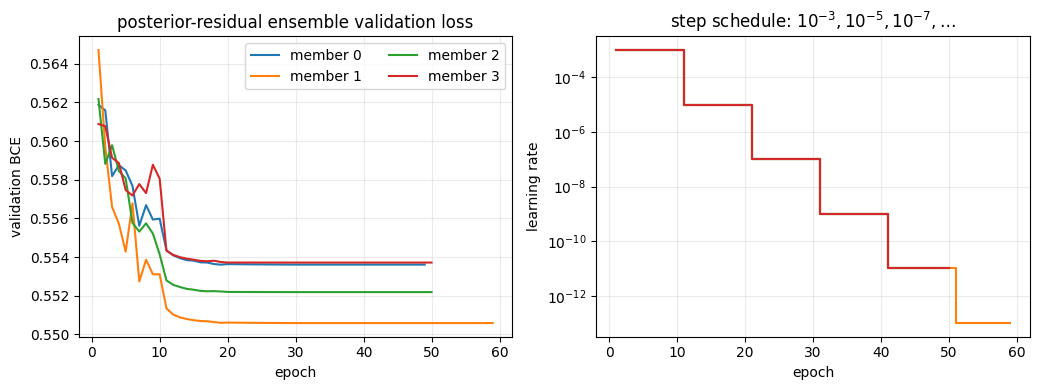

In [6]:
plot_ratio_training_histories(
    r_p_ensemble,
    title=r"posterior-residual ensemble validation loss",
    script_name="posterior_residual_ensemble_training",
)


## 3. Does hNPE correct the NPE?

For the fixed observation $x_o$, draw

$$
\theta_j\sim q_{\phi,\epsilon}(\theta\mid x_o),\qquad
u_j^{\rm P}=\widehat r_{\rm P}(\theta_j;x_o),\qquad
w_j^{\rm P}=\frac{u_j^{\rm P}}{\sum_k u_k^{\rm P}}.
$$

The effective sample size and Pareto-$\hat k$ are both reported. ESS
measures the overall concentration of the weights; Pareto-$\hat k$
specifically detects a dangerous upper tail.


hNPE ESS = 356,631 / 500,000 (71.3%)
hNPE Pareto-k = -0.971
hNPE maximum normalized weight = 4.601e-06
E_q[r_P] at x_obs = 1.0072
JS distance, truth vs NPE               : 0.2319
JS distance, truth vs defensive proposal: 0.2368
JS distance, truth vs hNPE              : 0.0372
Wrote standalone figure script: exercise9_figures_scripts/npe_hnpe_posterior_closure.py


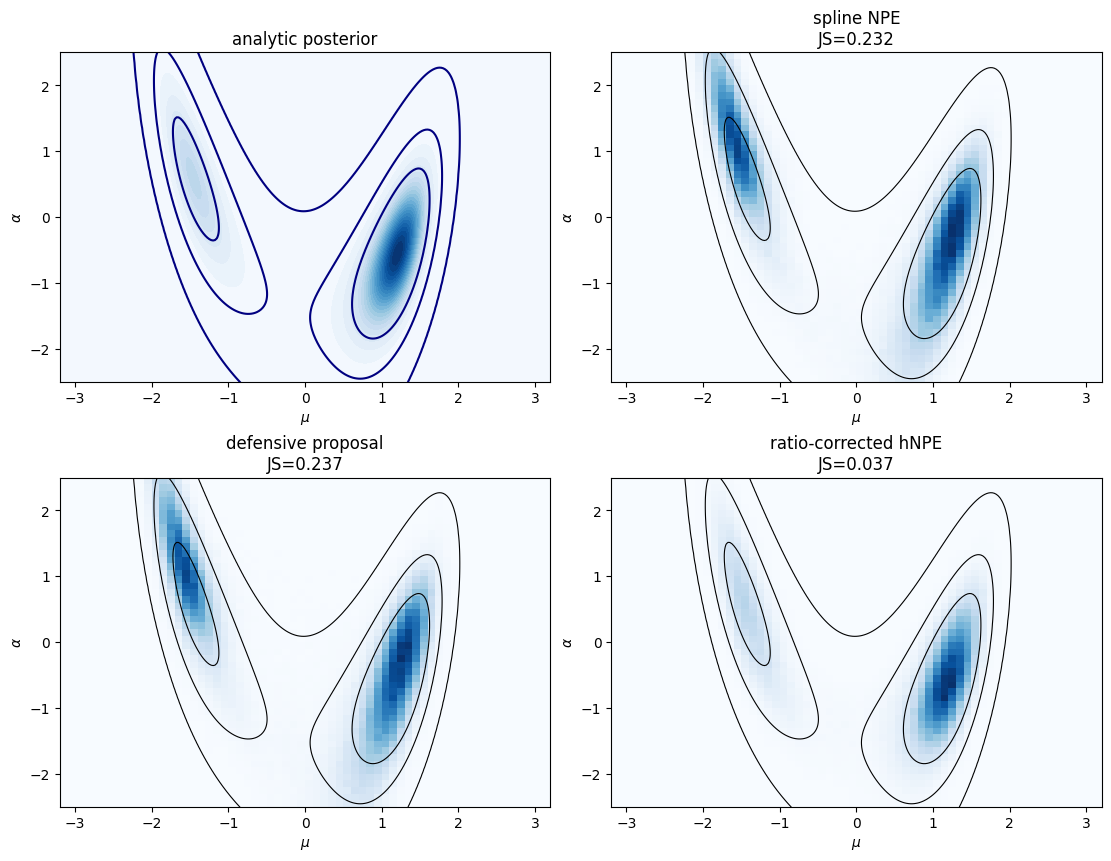

Wrote standalone figure script: exercise9_figures_scripts/npe_hnpe_mu_marginal.py


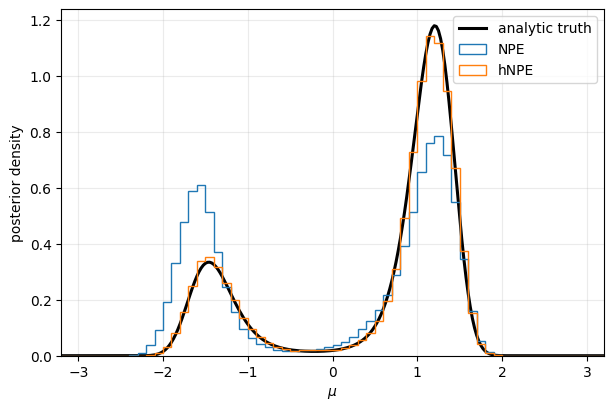

In [7]:
MU_GRID = np.linspace(-3.5, 3.5, 281)
ALPHA_GRID = np.linspace(-3.0, 3.0, 241)
MU_MESH, ALPHA_MESH = np.meshgrid(MU_GRID, ALPHA_GRID, indexing="ij")
THETA_GRID = np.column_stack([MU_MESH.ravel(), ALPHA_MESH.ravel()])

log_joint_truth = design_logpdf(THETA_GRID) + log_likelihood(X_OBS, THETA_GRID)
log_joint_truth = log_joint_truth.reshape(MU_MESH.shape)
truth_shift = float(log_joint_truth.max())
truth_unnormalized = np.exp(log_joint_truth - truth_shift)
truth_integral_scaled = np.trapezoid(
    np.trapezoid(truth_unnormalized, ALPHA_GRID, axis=1),
    MU_GRID,
)
LOG_EVIDENCE_TRUTH = truth_shift + np.log(truth_integral_scaled)
POSTERIOR_TRUTH = truth_unnormalized / truth_integral_scaled
TRUTH_MU = np.trapezoid(POSTERIOR_TRUTH, ALPHA_GRID, axis=1)
TRUTH_ALPHA = np.trapezoid(POSTERIOR_TRUTH, MU_GRID, axis=0)

rng = np.random.default_rng(SEED + 40)
x_context = X_OBS[None, :].astype(np.float32)
theta_npe = sample_spline_flow(q_phi, N_POSTERIOR, context=x_context)
theta_posterior = sample_defensive_fixed(X_OBS, N_POSTERIOR, rng)
rp_inputs = np.column_stack(
    [theta_posterior, np.repeat(x_context, len(theta_posterior), axis=0)]
)
log_rp = ratio_classifier_ensemble_logit(r_p_ensemble, rp_inputs)
weights_p = normalized_weights_from_log(log_rp)
tail_p = importance_tail_summary(log_rp)
print(
    f"hNPE ESS = {tail_p['ESS']:,.0f} / {len(weights_p):,} "
    f"({tail_p['ESS_fraction']:.1%})"
)
print(f"hNPE Pareto-k = {tail_p['pareto_k']:.3f}")
print(f"hNPE maximum normalized weight = {tail_p['max_weight_fraction']:.3e}")
print(f"E_q[r_P] at x_obs = {np.exp(logsumexp(log_rp) - np.log(len(log_rp))):.4f}")

MU_EDGES = np.linspace(-3.5, 3.5, 71)
ALPHA_EDGES = np.linspace(-3.0, 3.0, 61)
MU_CENTERS = 0.5 * (MU_EDGES[:-1] + MU_EDGES[1:])
ALPHA_CENTERS = 0.5 * (ALPHA_EDGES[:-1] + ALPHA_EDGES[1:])
MU_CELL, ALPHA_CELL = np.meshgrid(MU_CENTERS, ALPHA_CENTERS, indexing="ij")
THETA_CELL = np.column_stack([MU_CELL.ravel(), ALPHA_CELL.ravel()])
log_truth_cell = design_logpdf(THETA_CELL) + log_likelihood(X_OBS, THETA_CELL)
truth_probability = np.exp(log_truth_cell - logsumexp(log_truth_cell)).reshape(
    MU_CELL.shape
)

def histogram_probability(theta, weights=None):
    histogram = np.histogram2d(
        theta[:, 0], theta[:, 1], bins=[MU_EDGES, ALPHA_EDGES], weights=weights
    )[0]
    return histogram / histogram.sum()

def js_distance(p, q, floor=1.0e-12):
    p = np.asarray(p, dtype=float).ravel() + floor
    q = np.asarray(q, dtype=float).ravel() + floor
    p, q = p / p.sum(), q / q.sum()
    middle = 0.5 * (p + q)
    return np.sqrt(
        0.5 * np.sum(p * np.log(p / middle))
        + 0.5 * np.sum(q * np.log(q / middle))
    )

probability_npe = histogram_probability(theta_npe)
probability_defensive = histogram_probability(theta_posterior)
probability_hnpe = histogram_probability(theta_posterior, weights_p)
distances = {
    "NPE": js_distance(truth_probability, probability_npe),
    "defensive proposal": js_distance(truth_probability, probability_defensive),
    "hNPE": js_distance(truth_probability, probability_hnpe),
}
for name, value in distances.items():
    print(f"JS distance, truth vs {name:18s}: {value:.4f}")
if distances["hNPE"] >= distances["NPE"]:
    print("Warning: this stochastic fast run did not improve JS; use FAST_MODE=False.")

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), constrained_layout=True)
levels = np.quantile(POSTERIOR_TRUTH[POSTERIOR_TRUTH > 0], [0.65, 0.85, 0.95])
axes[0, 0].contourf(MU_GRID, ALPHA_GRID, POSTERIOR_TRUTH.T, levels=25, cmap="Blues")
axes[0, 0].contour(MU_GRID, ALPHA_GRID, POSTERIOR_TRUTH.T, levels=levels, colors="navy")
axes[0, 0].set_title("analytic posterior")
for ax, probability, title in [
    (axes[0, 1], probability_npe, "spline NPE"),
    (axes[1, 0], probability_defensive, "defensive proposal"),
    (axes[1, 1], probability_hnpe, "ratio-corrected hNPE"),
]:
    ax.pcolormesh(MU_EDGES, ALPHA_EDGES, probability.T, shading="auto", cmap="Blues")
    ax.contour(MU_GRID, ALPHA_GRID, POSTERIOR_TRUTH.T, levels=levels, colors="black", linewidths=0.8)
    ax.set_title(f"{title}\nJS={distances[title if title != 'spline NPE' else 'NPE']:.3f}" if title != "ratio-corrected hNPE" else f"{title}\nJS={distances['hNPE']:.3f}")
for ax in axes.flat:
    ax.set(xlabel=r"$\mu$", ylabel=r"$\alpha$", xlim=(-3.2, 3.2), ylim=(-2.5, 2.5))
export_exercise9_figure(fig, "npe_hnpe_posterior_closure")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(MU_GRID, TRUTH_MU, color="black", lw=2.2, label="analytic truth")
ax.hist(theta_npe[:, 0], bins=MU_EDGES, density=True, histtype="step", lw=1.8, label="NPE")
ax.hist(
    theta_posterior[:, 0], bins=MU_EDGES, weights=weights_p,
    density=True, histtype="step", lw=2.0, label="hNPE",
)
ax.set(xlabel=r"$\mu$", ylabel="posterior density", xlim=(-3.2, 3.2))
ax.legend()
ax.grid(alpha=0.25)
export_exercise9_figure(fig, "npe_hnpe_mu_marginal")
plt.show()


The correction should restore both the dominant positive-$\mu$ mode and the smaller negative-$\mu$ mode more accurately than the NPE alone. The defensive component is not itself the correction: it only places proposal events in regions that the ratio may need to upweight. The classifier odds determine the posterior shape.

A small ESS is not automatically a failure, but it is a warning that a few proposals dominate. If the ESS or maximum-weight diagnostic is poor, one should increase the defensive fraction, improve the NPE, or refine the simulation design before trusting tail-sensitive summaries.


## 4. Train conditional-reference hNDE

The likelihood-side flow now approximates the likelihood itself:

$$
q_\eta(x\mid\theta)\approx p(x\mid\theta).
$$

After freezing the flow, matched-$\theta$ classifier pairs are generated,

$$
\begin{aligned}
y=1:&\quad \theta_i\sim\rho,\quad x_i^+\sim p(x\mid\theta_i),\\
y=0:&\quad \text{the same }\theta_i,\quad
x_i^-\sim q_\eta(x\mid\theta_i).
\end{aligned}
$$

The classifier therefore learns only the residual

$$
c(x,\theta)=\frac{p(x\mid\theta)}{q_\eta(x\mid\theta)}.
$$

A finite classifier need not satisfy conditional normalization exactly.
We estimate and smoothly regress

$$
Z_{\rm C}(\theta)
=\mathbb E_{x\sim q_\eta(\cdot\mid\theta)}[c(x,\theta)]
$$

using flow samples only, and use

$$
\widehat p_{\rm hNDE}(x\mid\theta)
=q_\eta(x\mid\theta)
\frac{\widehat c(x,\theta)}{\widehat Z_{\rm C}(\theta)}.
$$


In [8]:
rng = np.random.default_rng(SEED + 50)
theta_eta = sample_design(N_FLOW, rng)
x_eta = simulate(theta_eta, rng)
q_eta = train_spline_flow(
    x_eta,
    context=theta_eta,
    checkpoint=MODEL_DIR / "q_eta_conditional_likelihood_reference.pt",
    model_config=FLOW_MODEL_CONFIG,
    training_config=FLOW_TRAINING_CONFIG,
    device=device,
    seed=SEED + 51,
    load_if_available=LOAD_IF_AVAILABLE,
)
del theta_eta, x_eta
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Training conditional quadratic-spline flow on 200,000 rows
  epoch 01/50: train=0.5271, validation=0.1672
  epoch 02/50: train=0.1842, validation=0.1307
  epoch 03/50: train=0.1241, validation=0.1206
  epoch 04/50: train=0.1114, validation=0.0666
  epoch 05/50: train=0.0890, validation=0.0638
  epoch 06/50: train=0.0935, validation=0.1559
  epoch 07/50: train=0.1037, validation=0.0833
  epoch 08/50: train=0.0653, validation=0.0789
  epoch 09/50: train=0.0163, validation=0.0166
  epoch 10/50: train=0.0085, validation=0.0151
  epoch 11/50: train=0.0094, validation=0.0037
  epoch 12/50: train=0.0067, validation=0.0062
  epoch 13/50: train=0.0074, validation=0.0136
  epoch 14/50: train=0.0077, validation=0.0084
  epoch 15/50: train=-0.0113, validation=-0.0044
  epoch 16/50: train=-0.0132, validation=-0.0064
  epoch 17/50: train=-0.0143, validation=-0.0056
  epoch 18/50: train=-0.0155, validation=-0.0066
  epoch 19/50: train=-0.0135, validation=0.0006
  epoch 20/50: train=-0.0138, validatio


Training conditional-residual member 1/4
Training balanced ratio classifier on 500,000 rows per class with paired_groups validation
  epoch 01/70: lr=1.000e-03, train=0.6905, validation=0.6884
  epoch 02/70: lr=1.000e-03, train=0.6889, validation=0.6882
  epoch 03/70: lr=1.000e-03, train=0.6887, validation=0.6878
  epoch 04/70: lr=1.000e-03, train=0.6885, validation=0.6878
  epoch 05/70: lr=1.000e-03, train=0.6884, validation=0.6885
  epoch 06/70: lr=1.000e-03, train=0.6885, validation=0.6880
  epoch 07/70: lr=1.000e-03, train=0.6886, validation=0.6888
  epoch 08/70: lr=1.000e-03, train=0.6882, validation=0.6880
  epoch 09/70: lr=1.000e-03, train=0.6883, validation=0.6880
  epoch 10/70: lr=1.000e-03, train=0.6881, validation=0.6877
  epoch 11/70: lr=1.000e-05, train=0.6878, validation=0.6876
  epoch 12/70: lr=1.000e-05, train=0.6877, validation=0.6875
  epoch 13/70: lr=1.000e-05, train=0.6876, validation=0.6875
  epoch 14/70: lr=1.000e-05, train=0.6876, validation=0.6875
  epoch 15/70

fold,path,member,validation_bce,log_ratio_q50,log_ratio_q95,log_ratio_q99,log_ratio_q999,log_ratio_max,mean_arithmetic_share,dominant_fraction
None,conditional hNDE residual,0,0.6874,-0.0005,0.0128,0.0242,0.0352,3.3055,0.2486,0.1766
None,conditional hNDE residual,1,0.6875,0.0009,0.0095,0.0140,0.0181,2.7506,0.2493,0.2136
None,conditional hNDE residual,2,0.6876,0.0020,0.0106,0.0141,0.0186,1.4001,0.2512,0.4034
None,conditional hNDE residual,3,0.6877,0.0001,0.0144,0.0366,0.0565,0.8709,0.2510,0.2064


Training conditional log normalizer on 1,638 parameter points (64 reference draws each)
  epoch 001/300: train=0.90927, validation=0.29362
  epoch 025/300: train=0.14621, validation=0.01922
  epoch 050/300: train=0.05282, validation=0.01794
  epoch 075/300: train=0.02868, validation=0.00806
  epoch 100/300: train=0.02177, validation=0.00678
  epoch 125/300: train=0.00806, validation=0.00477
  early stopping after 144 epochs
Saved conditional log normalizer to models_exercise9_dual_conditional_reference_v1/full/r_c_conditional_log_normalizer.pt
Wrote standalone figure script: exercise9_figures_scripts/conditional_residual_ensemble_training.py


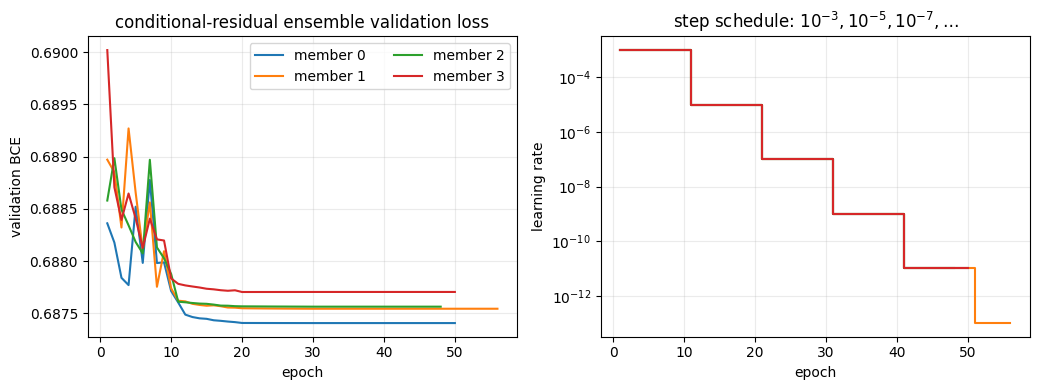

In [9]:
rng = np.random.default_rng(SEED + 60)
theta_rc = sample_design(N_RATIO, rng)
x_rc_positive = simulate(theta_rc, rng)
x_rc_negative = sample_spline_flow(
    q_eta, 1, context=theta_rc
)[:, 0, :]
rc_positive = np.column_stack([theta_rc, x_rc_positive])
rc_negative = np.column_stack([theta_rc, x_rc_negative])
paired_ids_rc = np.arange(N_RATIO, dtype=np.int64)
r_c_ensemble = []
for member in range(RATIO_ENSEMBLE_SIZE):
    print("\n" + "=" * 76)
    print(
        f"Training conditional-residual member "
        f"{member + 1}/{RATIO_ENSEMBLE_SIZE}"
    )
    print("=" * 76)
    r_c_ensemble.append(
        train_ratio_classifier(
            rc_positive,
            rc_negative,
            checkpoint=(
                RATIO_MODEL_DIR
                / f"r_c_conditional_residual_member{member}.pt"
            ),
            model_config=RATIO_MODEL_CONFIG,
            training_config=RATIO_TRAINING_CONFIG,
            device=device,
            seed=SEED + 61 + 100 * member,
            load_if_available=LOAD_IF_AVAILABLE,
            paired_group_ids=paired_ids_rc,
        )
    )

assert all(
    pack["history"].get("split_strategy") == "paired_groups"
    for pack in r_c_ensemble
)
rc_tail_rows = min(25_000, len(rc_negative))
display(
    ratio_member_tail_diagnostics(
        r_c_ensemble,
        rc_negative[:rc_tail_rows],
        path="conditional hNDE residual",
    ).style.format(precision=4).hide(axis="index")
)

theta_normalizer = sample_design(N_NORMALIZER_CONTEXT, rng)
hnde_log_normalizer = train_conditional_log_normalizer(
    q_eta,
    r_c_ensemble,
    theta_normalizer,
    checkpoint=MODEL_DIR / "r_c_conditional_log_normalizer.pt",
    device=device,
    seed=SEED + 65,
    n_reference=N_NORMALIZER_REFERENCE,
    load_if_available=LOAD_IF_AVAILABLE,
)

del (
    theta_rc,
    x_rc_positive,
    x_rc_negative,
    rc_positive,
    rc_negative,
    paired_ids_rc,
    theta_normalizer,
)
gc.collect()

plot_ratio_training_histories(
    r_c_ensemble,
    title=r"conditional-residual ensemble validation loss",
    script_name="conditional_residual_ensemble_training",
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()


### Conditional likelihood closure

Three independent checks are made before posterior inference:

1. an actual classifier two-sample test compares held-out simulator
   events with $q_\eta(x\mid\theta)$ draws at the same held-out
   parameters;
2. $Z_{\rm C}(\theta)$ is measured at many parameter points before and
   after the parameter-dependent correction;
3. at one fixed $\theta_0$, residual-reweighted flow draws are compared
   directly with simulator events.


c2st_accuracy,c2st_auc,c2st_symmetric_auc,c2st_binomial_pvalue,c2st_test_rows
0.5043,0.5140,0.5140,0.3240,3000


,raw_Z,corrected_Z
mean,1.0005,1.0224
std,0.0018,0.0944
min,0.9959,0.7190
max,1.0035,1.4278


E_qeta[c/Z_C] at theta_check = 1.020490855983967
conditional-generation ESS = 249,932 / 250,000; Pareto-k = -0.577
Wrote standalone figure script: exercise9_figures_scripts/conditional_reference_hnde_likelihood_closure.py


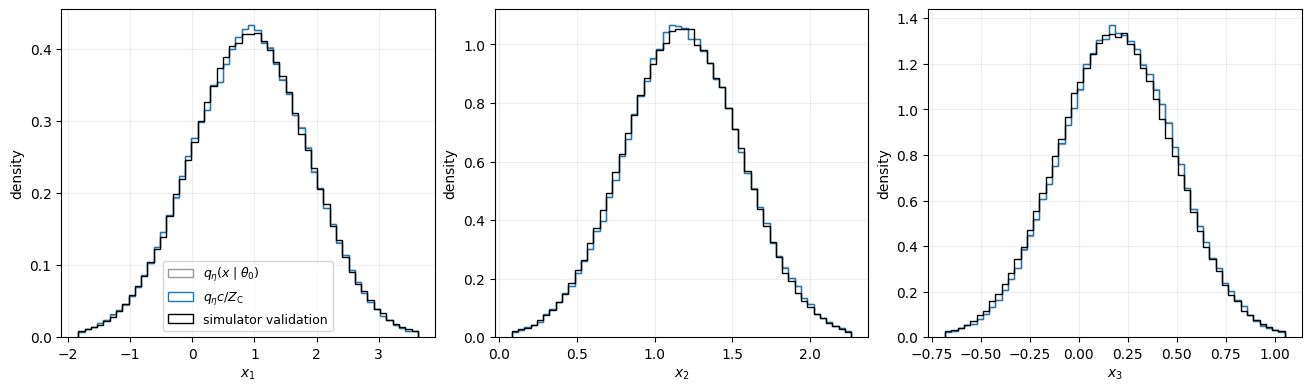

In [10]:
rng = np.random.default_rng(SEED + 70)

# Held-out conditional-flow C2ST with matched theta pairs kept together.
n_c2st = 2_000 if FAST_MODE else 5_000
theta_c2st = sample_design(n_c2st, rng)
x_c2st_simulator = simulate(theta_c2st, rng)
x_c2st_reference = sample_spline_flow(
    q_eta, 1, context=theta_c2st
)[:, 0, :]
c2st_result = conditional_flow_c2st(
    theta_c2st,
    x_c2st_simulator,
    x_c2st_reference,
    seed=SEED + 71,
)
display(pd.DataFrame([c2st_result]).style.format(precision=4).hide(axis="index"))

# Parameter-by-parameter residual normalization on new design points.
theta_normalization_check = sample_design(32, rng)
normalization_check = conditional_normalization_diagnostics(
    q_eta,
    r_c_ensemble,
    hnde_log_normalizer,
    theta_normalization_check,
    n_reference=128 if FAST_MODE else 256,
    seed=SEED + 72,
)
display(
    normalization_check.describe().loc[
        ["mean", "std", "min", "max"],
        ["raw_Z", "corrected_Z"],
    ].style.format(precision=4)
)
assert np.isfinite(normalization_check["corrected_Z"]).all()

THETA_CHECK = np.array([[1.2, -0.35]], dtype=np.float32)
x_reference_check = sample_spline_flow(
    q_eta, N_REFERENCE, context=THETA_CHECK
)
theta_reference_check = np.repeat(
    THETA_CHECK, len(x_reference_check), axis=0
)
log_rc_check = conditional_residual_log_ratio(
    r_c_ensemble,
    hnde_log_normalizer,
    theta_reference_check,
    x_reference_check,
)
weights_check = normalized_weights_from_log(log_rc_check)
x_simulator_check = simulate(
    np.repeat(THETA_CHECK, N_REFERENCE, axis=0), rng
)
tail_check = importance_tail_summary(log_rc_check)
print(
    "E_qeta[c/Z_C] at theta_check =",
    np.exp(logsumexp(log_rc_check) - np.log(len(log_rc_check))),
)
print(
    f"conditional-generation ESS = {tail_check['ESS']:,.0f} "
    f"/ {len(weights_check):,}; Pareto-k = {tail_check['pareto_k']:.3f}"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for index, ax in enumerate(axes):
    low, high = np.quantile(
        x_simulator_check[:, index], [0.002, 0.998]
    )
    bins = np.linspace(low, high, 55)
    ax.hist(
        x_reference_check[:, index], bins=bins, density=True,
        histtype="step", color="0.6", lw=1.4,
        label=r"$q_\eta(x\mid\theta_0)$",
    )
    ax.hist(
        x_reference_check[:, index], bins=bins, weights=weights_check,
        density=True, histtype="step", lw=2.0,
        label=r"$q_\eta c/Z_{\rm C}$",
    )
    ax.hist(
        x_simulator_check[:, index], bins=bins, density=True,
        histtype="step", color="black", ls="--", lw=1.8,
        label="simulator validation",
    )
    ax.set(xlabel=labels[index], ylabel="density")
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=9)
export_exercise9_figure(fig, "conditional_reference_hnde_likelihood_closure")
plt.show()


## 5. Verify hNPE--hNDE equivalence

The normalized hNDE likelihood is

$$
\widehat L_{\rm C}(x;\theta)
=q_\eta(x\mid\theta)
\frac{\widehat c(x,\theta)}{\widehat Z_{\rm C}(\theta)}.
$$

Its design evidence is

$$
p_\rho(x)=\int \rho(\theta)\widehat L_{\rm C}(x;\theta)\,d\theta.
$$

Bayes' theorem gives the bridge

$$
r_{\rm P}(\theta;x)
=
\frac{\rho(\theta)\widehat L_{\rm C}(x;\theta)}
{p_\rho(x)q_{\phi,\epsilon}(\theta\mid x)}.
$$

The factor $q_\eta(x\mid\theta)$ must remain in this expression; unlike
an unconditional reference it does not cancel as a constant in
$\theta$. The dual consensus below is the predeclared geometric mean of
the separately normalized hNPE and hNDE weights.


JS(truth, hNPE posterior) = 0.0372
JS(truth, hNDE posterior) = 0.0294
JS(truth, dual posterior) = 0.0275
JS(hNPE, hNDE)            = 0.0380
hNPE : ESS=356,631/500,000, Pareto-k=-0.971, max w=4.601e-06
hNDE : ESS=355,728/500,000, Pareto-k=-0.232, max w=4.534e-06
dual : ESS=357,032/500,000, Pareto-k=-0.655, max w=4.364e-06
log p_rho(x_obs) from conditional hNDE = -3.3535
median |log r_P - log bridge| = 0.065
RMS(log r_P - log bridge) = 0.642
Wrote standalone figure script: exercise9_figures_scripts/conditional_hnpe_hnde_dual_equivalence.py


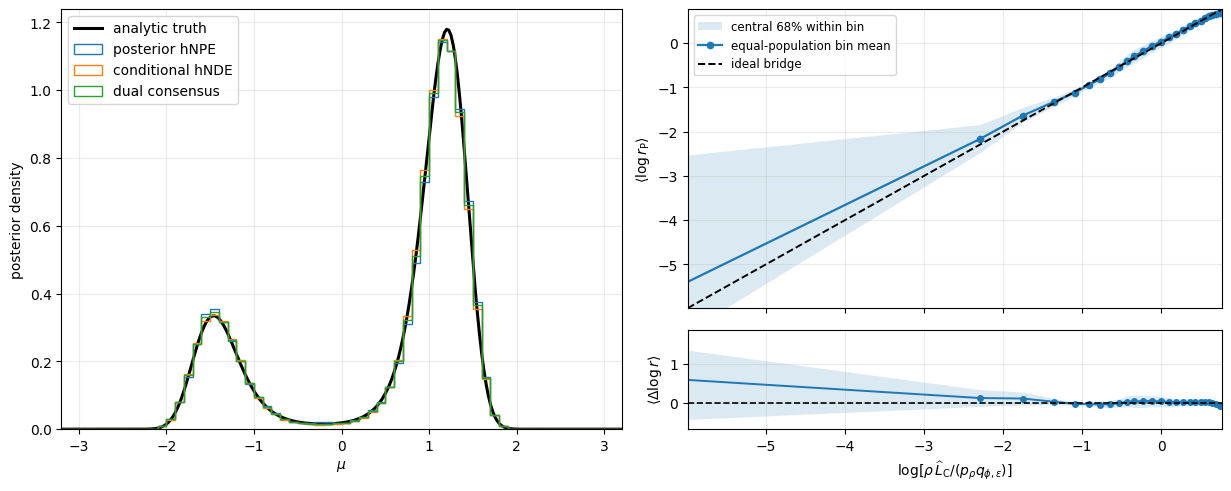

In [11]:
x_repeated = np.repeat(x_context, len(theta_posterior), axis=0)
log_rc_posterior = conditional_residual_log_ratio(
    r_c_ensemble,
    hnde_log_normalizer,
    theta_posterior,
    x_repeated,
)
log_qeta_posterior = spline_flow_log_prob(
    q_eta,
    x_repeated,
    context=theta_posterior,
)
log_likelihood_hnde = log_qeta_posterior + log_rc_posterior
log_q_defensive = defensive_logpdf(theta_posterior, X_OBS)
log_weights_l = (
    design_logpdf(theta_posterior)
    + log_likelihood_hnde
    - log_q_defensive
)
weights_l = normalized_weights_from_log(log_weights_l)
log_weights_dual = 0.5 * (
    log_rp - logsumexp(log_rp)
    + log_weights_l - logsumexp(log_weights_l)
)
weights_dual = normalized_weights_from_log(log_weights_dual)

probability_hnde_posterior = histogram_probability(
    theta_posterior, weights_l
)
probability_dual_posterior = histogram_probability(
    theta_posterior, weights_dual
)
distance_hnde = js_distance(
    truth_probability, probability_hnde_posterior
)
distance_dual_truth = js_distance(
    truth_probability, probability_dual_posterior
)
distance_routes = js_distance(
    probability_hnpe, probability_hnde_posterior
)
print(f"JS(truth, hNPE posterior) = {distances['hNPE']:.4f}")
print(f"JS(truth, hNDE posterior) = {distance_hnde:.4f}")
print(f"JS(truth, dual posterior) = {distance_dual_truth:.4f}")
print(f"JS(hNPE, hNDE)            = {distance_routes:.4f}")
for name, log_weights in [
    ("hNPE", log_rp),
    ("hNDE", log_weights_l),
    ("dual", log_weights_dual),
]:
    tail = importance_tail_summary(log_weights)
    print(
        f"{name:5s}: ESS={tail['ESS']:,.0f}/{len(log_weights):,}, "
        f"Pareto-k={tail['pareto_k']:.3f}, "
        f"max w={tail['max_weight_fraction']:.3e}"
    )

rng = np.random.default_rng(SEED + 80)
theta_evidence_bridge = sample_design(N_REFERENCE, rng)
x_evidence_bridge = np.repeat(
    x_context, len(theta_evidence_bridge), axis=0
)
log_likelihood_evidence_bridge = (
    spline_flow_log_prob(
        q_eta,
        x_evidence_bridge,
        context=theta_evidence_bridge,
    )
    + conditional_residual_log_ratio(
        r_c_ensemble,
        hnde_log_normalizer,
        theta_evidence_bridge,
        x_evidence_bridge,
    )
)
log_evidence_bridge = (
    logsumexp(log_likelihood_evidence_bridge)
    - np.log(len(log_likelihood_evidence_bridge))
)
log_bridge = (
    design_logpdf(theta_posterior)
    + log_likelihood_hnde
    - log_evidence_bridge
    - log_q_defensive
)
bridge_subset = rng.choice(
    len(log_rp), min(20_000, len(log_rp)), replace=False
)
bridge_x = log_bridge[bridge_subset]
bridge_y = log_rp[bridge_subset]
bridge_delta = bridge_y - bridge_x
print(f"log p_rho(x_obs) from conditional hNDE = {log_evidence_bridge:.4f}")
print(
    "median |log r_P - log bridge| = "
    f"{np.median(np.abs(bridge_delta)):.3f}"
)
print(
    "RMS(log r_P - log bridge) = "
    f"{np.sqrt(np.mean(bridge_delta**2)):.3f}"
)

n_bridge_bins = min(25, len(bridge_subset))
bridge_groups = np.array_split(np.argsort(bridge_x), n_bridge_bins)
bridge_bin_x = np.array(
    [np.mean(bridge_x[group]) for group in bridge_groups]
)
bridge_bin_y = np.array(
    [np.mean(bridge_y[group]) for group in bridge_groups]
)
bridge_bin_y_q16 = np.array(
    [np.quantile(bridge_y[group], 0.16) for group in bridge_groups]
)
bridge_bin_y_q84 = np.array(
    [np.quantile(bridge_y[group], 0.84) for group in bridge_groups]
)
bridge_bin_delta = bridge_bin_y - bridge_bin_x
bridge_bin_delta_q16 = np.array(
    [np.quantile(bridge_delta[group], 0.16) for group in bridge_groups]
)
bridge_bin_delta_q84 = np.array(
    [np.quantile(bridge_delta[group], 0.84) for group in bridge_groups]
)

fig = plt.figure(figsize=(12.2, 4.8), constrained_layout=True)
grid = fig.add_gridspec(
    2, 2, width_ratios=(1.05, 1.0), height_ratios=(3.0, 1.0)
)
posterior_ax = fig.add_subplot(grid[:, 0])
closure_ax = fig.add_subplot(grid[0, 1])
residual_ax = fig.add_subplot(grid[1, 1], sharex=closure_ax)

posterior_ax.plot(
    MU_GRID, TRUTH_MU, color="black", lw=2.2, label="analytic truth"
)
for weights, label, linestyle in [
    (weights_p, "posterior hNPE", "-"),
    (weights_l, "conditional hNDE", "--"),
    (weights_dual, "dual consensus", ":"),
]:
    posterior_ax.hist(
        theta_posterior[:, 0], bins=MU_EDGES, weights=weights,
        density=True, histtype="step", lw=2, ls=linestyle, label=label,
    )
posterior_ax.set(
    xlabel=r"$\mu$", ylabel="posterior density", xlim=(-3.2, 3.2)
)
posterior_ax.legend()
posterior_ax.grid(alpha=0.25)

closure_ax.fill_between(
    bridge_bin_x, bridge_bin_y_q16, bridge_bin_y_q84,
    color="C0", alpha=0.16, linewidth=0,
    label="central 68% within bin",
)
closure_ax.plot(
    bridge_bin_x, bridge_bin_y, marker="o", ms=4.5, lw=1.6,
    color="C0", label="equal-population bin mean",
)
low = np.quantile(np.concatenate([bridge_x, bridge_y]), 0.01)
high = np.quantile(np.concatenate([bridge_x, bridge_y]), 0.99)
closure_ax.plot(
    [low, high], [low, high], color="black", ls="--", lw=1.4,
    label="ideal bridge",
)
closure_ax.set(
    ylabel=r"$\langle\log r_{\rm P}\rangle$",
    xlim=(low, high), ylim=(low, high),
)
closure_ax.tick_params(labelbottom=False)
closure_ax.legend(fontsize=8.5)
closure_ax.grid(alpha=0.25)

residual_ax.fill_between(
    bridge_bin_x, bridge_bin_delta_q16, bridge_bin_delta_q84,
    color="C0", alpha=0.16, linewidth=0,
)
residual_ax.plot(
    bridge_bin_x, bridge_bin_delta, marker="o", ms=4.0,
    lw=1.4, color="C0",
)
residual_ax.axhline(0.0, color="black", ls="--", lw=1.2)
residual_ax.set(
    xlabel=r"$\log[\rho\,\widehat L_{\rm C}/(p_\rho q_{\phi,\epsilon})]$",
    ylabel=r"$\langle\Delta\log r\rangle$", xlim=(low, high),
)
residual_ax.grid(alpha=0.25)
export_exercise9_figure(fig, "conditional_hnpe_hnde_dual_equivalence")
plt.show()


## What the dual model adds

| capability | posterior hNPE | conditional-reference hNDE |
|---|---:|---:|
| fast parameter proposals | direct | use hNPE or another proposal |
| residual correction | $r_{\rm P}$ | $c/Z_{\rm C}$ |
| normalized conditional generator | no | $q_\eta(x\mid\theta)c/Z_{\rm C}$ |
| absolute likelihood and evidence | no | yes |
| alternative supported priors | importance reweighting | posterior/evidence integral |
| selection and population integrals | not by itself | conditional-flow expectation |

The conditional reference makes the likelihood ratio genuinely residual
and improves conditional generation. The bookkeeping is less
cancellative: $q_\eta(x_o\mid\theta)$ must be retained in posterior and
evidence integrals.


## 6. Posterior-predictive generation without the simulator

Draw corrected posterior parameters and then draw directly from the
conditional likelihood reference:

$$
\theta_j\sim p_\rho(\theta\mid x_o),\qquad
x_j^\star\sim q_\eta(x\mid\theta_j).
$$

Weighting each pair by

$$
\frac{c(x_j^\star,\theta_j)}{Z_{\rm C}(\theta_j)}
$$

gives the posterior predictive. Because $q_\eta(x\mid\theta)$ is already
trained as an approximate likelihood, these weights should be much
closer to one than with an unconditional observation reference.


posterior-predictive ESS = 149,959 / 150,000; Pareto-k=-0.241
Wrote standalone figure script: exercise9_figures_scripts/posterior_predictive_conditional_reference.py


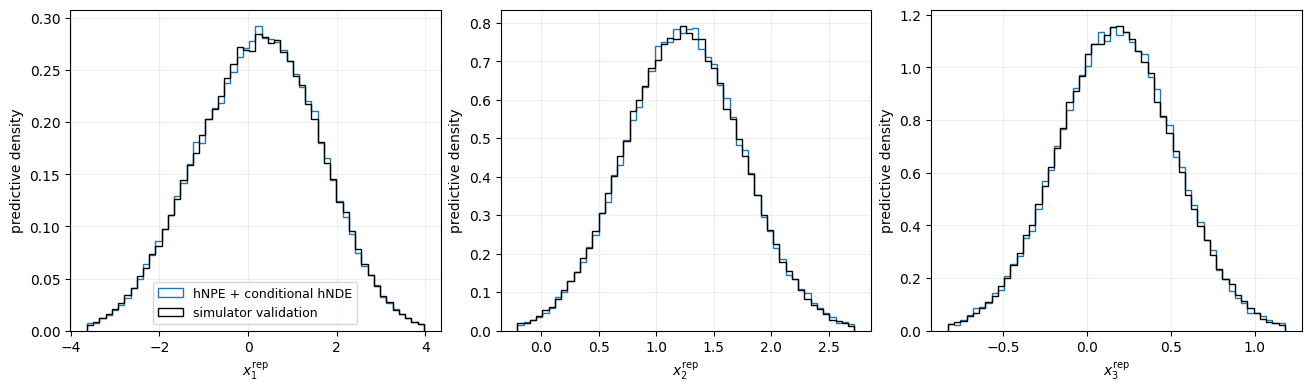

In [12]:
rng = np.random.default_rng(SEED + 90)
N_PREDICTIVE = 50_000 if FAST_MODE else 150_000
theta_predictive = theta_posterior[
    rng.choice(
        len(theta_posterior),
        size=N_PREDICTIVE,
        replace=True,
        p=weights_p,
    )
]
x_predictive_proposal = sample_spline_flow(
    q_eta, 1, context=theta_predictive
)[:, 0, :]
log_predictive_weights = conditional_residual_log_ratio(
    r_c_ensemble,
    hnde_log_normalizer,
    theta_predictive,
    x_predictive_proposal,
)
predictive_weights = normalized_weights_from_log(log_predictive_weights)
predictive_indices = rng.choice(
    N_PREDICTIVE,
    size=N_PREDICTIVE,
    replace=True,
    p=predictive_weights,
)
x_predictive_hnde = x_predictive_proposal[predictive_indices]
predictive_tail = importance_tail_summary(log_predictive_weights)
print(
    f"posterior-predictive ESS = {predictive_tail['ESS']:,.0f} "
    f"/ {N_PREDICTIVE:,}; Pareto-k={predictive_tail['pareto_k']:.3f}"
)

# Validation only: this call is not part of the simulator-free generator.
x_predictive_simulator = simulate(theta_predictive, rng)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)
for index, ax in enumerate(axes):
    combined = np.concatenate(
        [x_predictive_hnde[:, index], x_predictive_simulator[:, index]]
    )
    low, high = np.quantile(combined, [0.002, 0.998])
    bins = np.linspace(low, high, 55)
    ax.hist(
        x_predictive_hnde[:, index], bins=bins, density=True,
        histtype="step", lw=2.0,
        label="hNPE + conditional hNDE",
    )
    ax.hist(
        x_predictive_simulator[:, index], bins=bins, density=True,
        histtype="step", color="black", ls="--", lw=1.8,
        label="simulator validation",
    )
    ax.set(
        xlabel=rf"$x_{index + 1}^{{\rm rep}}$",
        ylabel="predictive density",
    )
    ax.grid(alpha=0.2)
axes[0].legend(fontsize=9)
export_exercise9_figure(
    fig, "posterior_predictive_conditional_reference"
)
plt.show()


## 7. Absolute evidence

With a conditional reference the evidence is

$$
p_\pi(x_o)
=
\int \pi(\theta)q_\eta(x_o\mid\theta)
\frac{c(x_o,\theta)}{Z_{\rm C}(\theta)}\,d\theta.
$$

The flow density cannot be taken outside this integral because it
depends on $\theta$. Absolute evidence remains available, but it now
requires the full normalized conditional likelihood at every sampled
parameter point.


In [13]:
rng = np.random.default_rng(SEED + 100)
N_EVIDENCE = 80_000 if FAST_MODE else 300_000
theta_evidence = sample_design(N_EVIDENCE, rng)
x_evidence = np.repeat(x_context, N_EVIDENCE, axis=0)
log_qeta_evidence = spline_flow_log_prob(
    q_eta,
    x_evidence,
    context=theta_evidence,
)
log_rc_evidence = conditional_residual_log_ratio(
    r_c_ensemble,
    hnde_log_normalizer,
    theta_evidence,
    x_evidence,
)
log_likelihood_evidence = log_qeta_evidence + log_rc_evidence
log_evidence_hnde = (
    logsumexp(log_likelihood_evidence) - np.log(N_EVIDENCE)
)
scaled_integrand = np.exp(
    log_likelihood_evidence - np.max(log_likelihood_evidence)
)
relative_mc_error = scaled_integrand.std(ddof=1) / (
    np.sqrt(N_EVIDENCE) * scaled_integrand.mean()
)

print(f"log evidence from conditional hNDE          = {log_evidence_hnde: .5f}")
print(f"log evidence from numerical truth          = {LOG_EVIDENCE_TRUTH: .5f}")
print(
    "difference (conditional hNDE - truth)       = "
    f"{log_evidence_hnde - LOG_EVIDENCE_TRUTH: .5f}"
)
print(
    "MC-only relative error on evidence integral = "
    f"{relative_mc_error:.2%}"
)


log evidence from conditional hNDE          = -3.36021
log evidence from numerical truth          = -3.37419
difference (conditional hNDE - truth)       =  0.01398
MC-only relative error on evidence integral = 0.47%


## 8. Nuisance-prior and auxiliary-likelihood update

The NPE and residual were trained under $\rho(\mu,\alpha)$ using only the principal observation $x$. We now replace the nuisance prior by

$$
  \pi_{\rm new}(\alpha)=\mathcal N(0.30,0.45^2)
$$

and add an auxiliary measurement

$$
  a_o=0.10,\qquad f(a_o\mid\alpha)=\mathcal N(a_o;\alpha,0.25^2).
$$

The $\mu$ prior is unchanged. Existing defensive candidates receive

$$
  u_j^{\rm new}=r_{\rm P}(\theta_j;x_o)
  \frac{\pi_{\rm new}(\alpha_j)}{\rho(\alpha_j)}
  f(a_o\mid\alpha_j).
$$

No neural model is retrained. The update is valid because the defensive design has adequate support where the new prior and auxiliary likelihood are appreciable. The ESS quantifies whether that formal support is practically useful.


updated-posterior ESS = 111,893 / 500,000 (22.4%)
Wrote standalone figure script: exercise9_figures_scripts/nuisance_prior_auxiliary_update.py


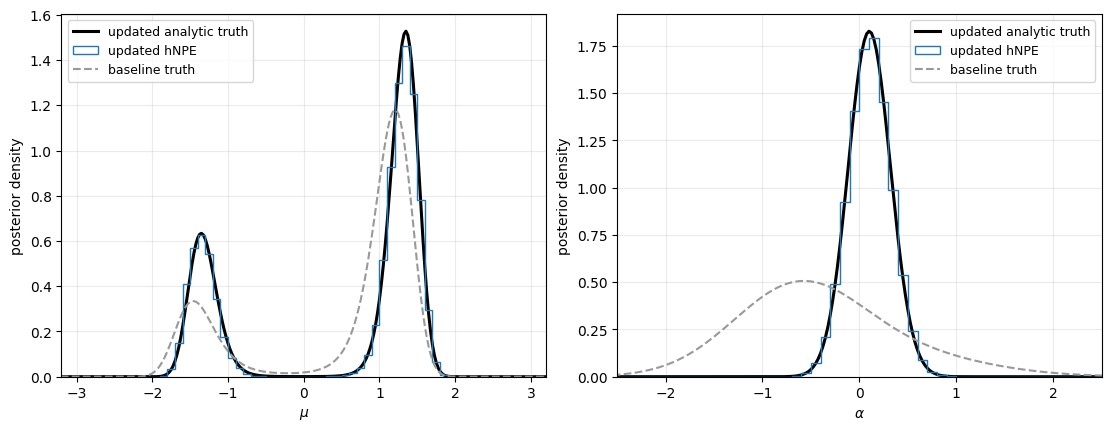

In [14]:
ALPHA_PRIOR_MEAN = 0.30
ALPHA_PRIOR_SIGMA = 0.45
A_OBSERVED = 0.10
SIGMA_A = 0.25

log_prior_update = (
    norm.logpdf(
        theta_posterior[:, 1], loc=ALPHA_PRIOR_MEAN, scale=ALPHA_PRIOR_SIGMA
    )
    - design_alpha_logpdf(theta_posterior[:, 1])
)
log_auxiliary = auxiliary_loglikelihood(
    theta_posterior[:, 1], A_OBSERVED, SIGMA_A
)
log_weights_update = log_rp + log_prior_update + log_auxiliary
weights_update = normalized_weights_from_log(log_weights_update)
print(
    f"updated-posterior ESS = {effective_sample_size(weights_update):,.0f} / "
    f"{len(weights_update):,} "
    f"({effective_sample_size(weights_update) / len(weights_update):.1%})"
)

log_joint_update = (
    design_mu_logpdf(THETA_GRID[:, 0])
    + norm.logpdf(
        THETA_GRID[:, 1], loc=ALPHA_PRIOR_MEAN, scale=ALPHA_PRIOR_SIGMA
    )
    + log_likelihood(X_OBS, THETA_GRID)
    + auxiliary_loglikelihood(THETA_GRID[:, 1], A_OBSERVED, SIGMA_A)
).reshape(MU_MESH.shape)
update_shift = log_joint_update.max()
update_unnormalized = np.exp(log_joint_update - update_shift)
update_integral = np.trapezoid(
    np.trapezoid(update_unnormalized, ALPHA_GRID, axis=1), MU_GRID
)
posterior_update_truth = update_unnormalized / update_integral
update_mu_truth = np.trapezoid(posterior_update_truth, ALPHA_GRID, axis=1)
update_alpha_truth = np.trapezoid(posterior_update_truth, MU_GRID, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(MU_GRID, update_mu_truth, color="black", lw=2.2, label="updated analytic truth")
axes[0].hist(
    theta_posterior[:, 0], bins=MU_EDGES, weights=weights_update,
    density=True, histtype="step", lw=2.0, label="updated hNPE",
)
axes[0].plot(MU_GRID, TRUTH_MU, color="0.6", ls="--", label="baseline truth")
axes[0].set(xlabel=r"$\mu$", ylabel="posterior density", xlim=(-3.2, 3.2))
axes[1].plot(
    ALPHA_GRID, update_alpha_truth, color="black", lw=2.2,
    label="updated analytic truth",
)
axes[1].hist(
    theta_posterior[:, 1], bins=ALPHA_EDGES, weights=weights_update,
    density=True, histtype="step", lw=2.0, label="updated hNPE",
)
axes[1].plot(ALPHA_GRID, TRUTH_ALPHA, color="0.6", ls="--", label="baseline truth")
axes[1].set(xlabel=r"$\alpha$", ylabel="posterior density", xlim=(-2.5, 2.5))
for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
export_exercise9_figure(fig, "nuisance_prior_auxiliary_update")
plt.show()


## 9. Selection integrals without the simulator

Suppose an event is retained when

$$
I_{\rm sel}(x)=\mathbf 1[x_1>0.5]\,\mathbf 1[x_3>0].
$$

At fixed parameters,

$$
\beta(\theta)
=
\mathbb E_{x\sim q_\eta(\cdot\mid\theta)}
\left[
I_{\rm sel}(x)\frac{c(x,\theta)}{Z_{\rm C}(\theta)}
\right].
$$

Unlike the unconditional-reference construction, one common observation
sample cannot be reused for every $\theta$; the conditional flow is
sampled at each requested parameter point. This is normally efficient
because it already generates near the desired conditional density.


alpha=-0.7: max |E_q[c/Z_C]-1| = 162.507
alpha=+0.0: max |E_q[c/Z_C]-1| = 2263782021680.886
alpha=+0.7: max |E_q[c/Z_C]-1| = 825421695.142
Wrote standalone figure script: exercise9_figures_scripts/conditional_reference_selection_integrals.py


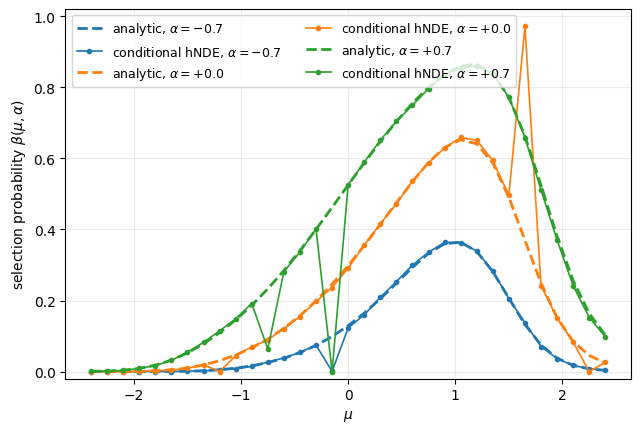

In [15]:
X1_THRESHOLD = 0.5
X3_THRESHOLD = 0.0
N_SELECTION_REFERENCE = 5_000 if FAST_MODE else 20_000
MU_SELECTION = np.linspace(-2.4, 2.4, 33)
ALPHA_SELECTION = [-0.7, 0.0, 0.7]


def exact_selection_probability(theta):
    mean = simulator_mean(theta)
    return norm.sf(
        (X1_THRESHOLD - mean[:, 0]) / SIMULATOR_SIGMA[0]
    ) * norm.sf(
        (X3_THRESHOLD - mean[:, 2]) / SIMULATOR_SIGMA[2]
    )


selection_results = {}
normalization_results = {}
for alpha in ALPHA_SELECTION:
    estimates, normalizations = [], []
    for mu in MU_SELECTION:
        theta_value = np.array([[mu, alpha]], dtype=np.float32)
        x_selection_reference = sample_spline_flow(
            q_eta,
            N_SELECTION_REFERENCE,
            context=theta_value,
        )
        theta_repeated = np.repeat(
            theta_value, N_SELECTION_REFERENCE, axis=0
        )
        log_ratio = conditional_residual_log_ratio(
            r_c_ensemble,
            hnde_log_normalizer,
            theta_repeated,
            x_selection_reference,
        )
        ratio = np.exp(log_ratio - np.max(log_ratio))
        selection_indicator = (
            (x_selection_reference[:, 0] > X1_THRESHOLD)
            & (x_selection_reference[:, 2] > X3_THRESHOLD)
        )
        estimates.append(
            np.sum(selection_indicator * ratio) / np.sum(ratio)
        )
        normalizations.append(
            np.exp(logsumexp(log_ratio) - np.log(len(log_ratio)))
        )
    selection_results[alpha] = np.asarray(estimates)
    normalization_results[alpha] = np.asarray(normalizations)

fig, ax = plt.subplots(figsize=(7.3, 4.8))
colors = ["C0", "C1", "C2"]
for color, alpha in zip(colors, ALPHA_SELECTION):
    theta_line = np.column_stack(
        [MU_SELECTION, np.full_like(MU_SELECTION, alpha)]
    )
    exact = exact_selection_probability(theta_line)
    ax.plot(
        MU_SELECTION, exact, color=color, ls="--", lw=2,
        label=rf"analytic, $\alpha={alpha:+.1f}$",
    )
    ax.plot(
        MU_SELECTION, selection_results[alpha], color=color,
        marker="o", ms=3, lw=1.2,
        label=rf"conditional hNDE, $\alpha={alpha:+.1f}$",
    )
    max_norm_error = np.max(
        np.abs(normalization_results[alpha] - 1.0)
    )
    print(
        f"alpha={alpha:+.1f}: "
        f"max |E_q[c/Z_C]-1| = {max_norm_error:.3f}"
    )
ax.set(
    xlabel=r"$\mu$",
    ylabel=r"selection probability $\beta(\mu,\alpha)$",
    ylim=(-0.02, 1.02),
)
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.25)
export_exercise9_figure(
    fig, "conditional_reference_selection_integrals"
)
plt.show()


## Conclusions and limitations

This exercise built the dual factorization

$$
p_\rho(\theta\mid x)
=q_{\phi,\epsilon}(\theta\mid x)r_{\rm P}(\theta;x),
\qquad
p(x\mid\theta)
=q_\eta(x\mid\theta)
\frac{c(x,\theta)}{Z_{\rm C}(\theta)}.
$$

The conditional likelihood flow now performs the main density-estimation
work, while the classifier learns a residual expected to be near one.
The advantages of the dual construction are preserved: rapid posterior
proposals, an independent likelihood-side check, conditional
generation, posterior prediction, evidence, prior updates, and
selection integrals.

Five safeguards are explicit:

1. paired classifier rows are grouped before train/validation splitting;
2. the conditional flow is tested against held-out simulator data with
   C2ST;
3. $Z_{\rm C}(\theta)$ is checked at many held-out parameter points;
4. each ratio member's upper tail and arithmetic-ensemble dominance are
   reported;
5. ESS and Pareto-$\hat k$ accompany every important weighting step.

The conditional normalizer is itself an approximation. A poor
extrapolation of $\widehat Z_{\rm C}(\theta)$, missing support, or a
misspecified simulator can still bias inference. Agreement between hNPE
and hNDE remains necessary but not sufficient.
